# Implementation of MCP Neuron for AND and OR Function.

In [129]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operation with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value.

    Returns:
    state_neuron (list): Output of neuron (1 or 0).
    """

    assert len(X1) == len(X2)

    state_neuron = []  # to store outputs

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [130]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [131]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operation with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [132]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


In [133]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


#Question-1:What does the shape of X represent?

The shape of X represents the number of images (samples) and the number of features (784 pixels per image).

#Question-2:What does the shape of Y represent?

The shape of y represents the corresponding labels for each image.

### Viewing the Dataset.

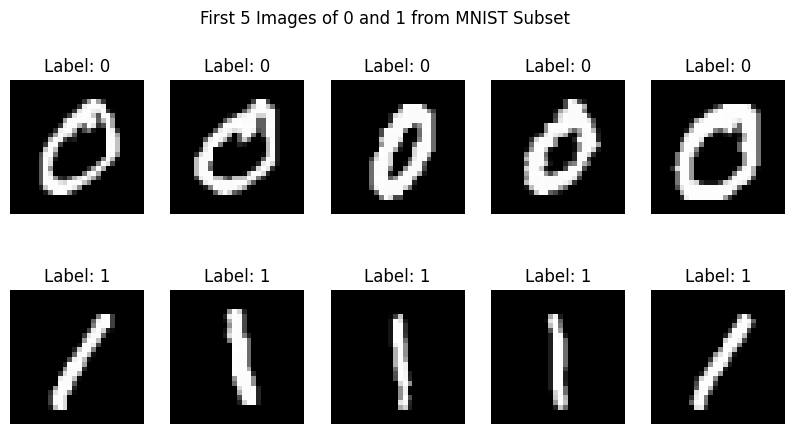

In [135]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [136]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

#Question-3:What does the weights array represent in this context?


The weights represent how important each pixel is in influencing the model’s prediction.

#Question-4: Why are we initializing the weights to zero? What effect could this have on the tranning process?

 We initialize weights to zero to start with no bias so the model learns from data, though it may slow initial learning slightly.


## Step - 3 - Make a Decision function:

In [137]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """
    predictions = np.dot(X, weights) + bias

    # Step activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [138]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for _ in range(epochs):
        for i in range(len(X)):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation
            y_pred = 1 if linear_output >= 0 else 0

            # Error
            error = y[i] - y_pred

            # Update rule (only changes if error != 0)
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    # Final predictions for accuracy
    y_pred_all = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(y_pred_all == y)

    return weights, bias, accuracy

#Question-5:What is the purpose of the output= np.dot(X[i],weights)+bias line?

The line computes the weighted sum of inputs plus bias, which determines the neuron’s decision before applying the activation function.

#Question-6:What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is wrong, the weights and bias are adjusted using the error to push the model toward the correct output.

#Question-7:Why is the final accuracy important, and what do you expect it to be?

The final accuracy is important because it measures how well the model is able to correctly classify the data, indicating the overall performance and effectiveness of the perceptron

## Training the Perceptron

In [139]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.0106


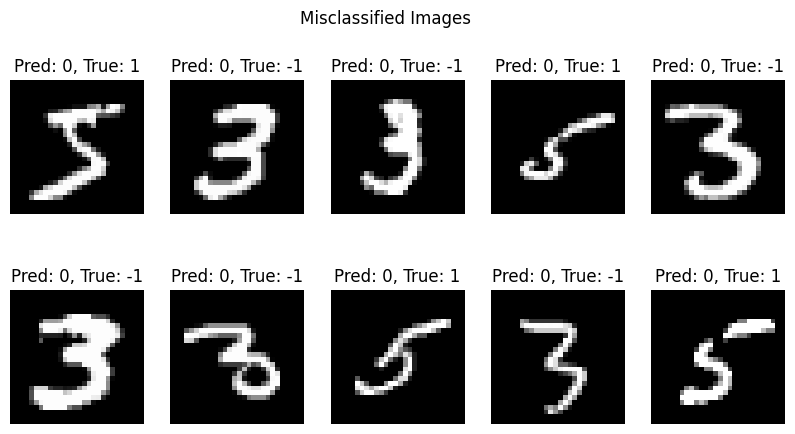

In [143]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

#Question-8:What does misclassifieed_idx store, and how is it used in this code?

Misclassified_idx stores the indices (positions) of all data points where the model made a wrong prediction.

#Question-9:How do you interpret the result if the output is"All images were correctly classified"?

If the output is “All images were correctly classified,” it means that the model made no prediction errors and achieved 100% accuracy, with every predicted label matching the true label. This indicates that the dataset is likely linearly separable, allowing the perceptron to find a decision boundary that perfectly distinguishes between the two classes.

**Task3:Perception Algorithm for 3 vs 5 Classification**

#Step 1: Load and Pre-prepare data

First few rows:
    label  pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  \
0      5        0        0        0        0        0        0        0   
1      3        0        0        0        0        0        0        0   
2      3        0        0        0        0        0        0        0   
3      5        0        0        0        0        0        0        0   
4      3        0        0        0        0        0        0        0   

   pixel_7  pixel_8  ...  pixel_774  pixel_775  pixel_776  pixel_777  \
0        0        0  ...        0.0        0.0        0.0        0.0   
1        0        0  ...        0.0        0.0        0.0        0.0   
2        0        0  ...        0.0        0.0        0.0        0.0   
3        0        0  ...        0.0        0.0        0.0        0.0   
4        0        0  ...        0.0        0.0        0.0        0.0   

   pixel_778  pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  
0        0.0        0.0      

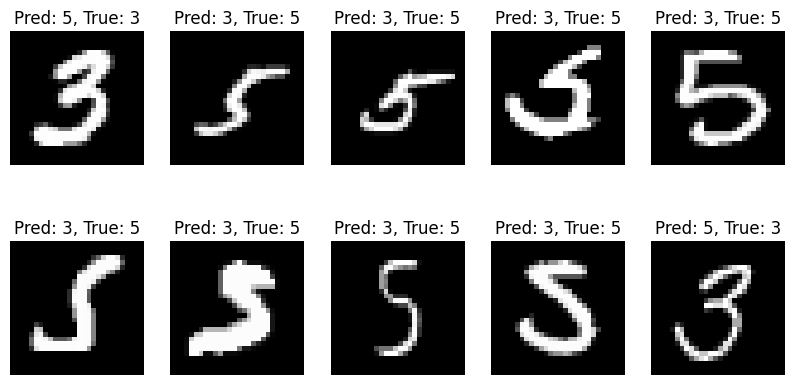

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# STEP 2: LOAD DATA
data = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_3_and_5.csv")

print("First few rows:\n", data.head())
# STEP 3: AUTO-DETECT LABEL COLUMN
# Check if label is first or last
first_col_unique = data.iloc[:, 0].unique()
last_col_unique = data.iloc[:, -1].unique()

if set(first_col_unique).issubset({3, 5}):
    print("Label is FIRST column")
    y = data.iloc[:, 0].values
    X = data.iloc[:, 1:].values
elif set(last_col_unique).issubset({3, 5}):
    print("Label is LAST column")
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
else:
    raise ValueError("Could not detect label column (expected values 3 and 5)")

# STEP 4: PREPROCESS
# Convert labels: 3 → -1, 5 → +1
y = np.where(y == 3, -1, 1)

# Normalize
X = X / 255.0
# STEP 5: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# STEP 6: INITIALIZE MODEL
weights = np.zeros(X_train.shape[1])
bias = 0
learning_rate = 0.01
epochs = 5

# STEP 7: TRAIN PERCEPTRON
for epoch in range(epochs):
    for i in range(len(X_train)):
        linear_output = np.dot(X_train[i], weights) + bias
        prediction = 1 if linear_output >= 0 else -1

        if prediction != y_train[i]:
            weights += learning_rate * y_train[i] * X_train[i]
            bias += learning_rate * y_train[i]

# STEP 8: PREDICTION
def predict(X):
    linear_output = np.dot(X, weights) + bias
    return np.where(linear_output >= 0, 1, -1)

y_pred = predict(X_test)

# STEP 9: EVALUATE
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

misclassified = np.where(y_pred != y_test)[0]
print("Misclassified:", len(misclassified))

# STEP 10: VISUALIZATION
plt.figure(figsize=(10,5))

# If misclassified exist → show them
if len(misclassified) > 0:
    print("Showing misclassified images...")
    selected = misclassified[:10]

# Otherwise → show random samples
else:
    print("No misclassified → showing random samples")
    selected = np.random.choice(len(X_test), 10)

for i, index in enumerate(selected):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')

    # Convert back to original labels
    pred_label = 3 if y_pred[index] == -1 else 5
    true_label = 3 if y_test[index] == -1 else 5

    plt.title(f"Pred: {pred_label}, True: {true_label}")
    plt.axis('off')

plt.show()

#Final Conclusion

The Perceptron model was implemented to classify digits 3 and 5. The model achieved an accuracy of approximately 93%, but several misclassified images were observed. These errors occur due to the similarity in shapes between digits 3 and 5. Since the Perceptron is a linear classifier, it cannot perfectly separate overlapping patterns, which leads to misclassification.